In [ ]:
/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv

In [ ]:
# diabetes.csv 파일을 바탕으로 LR, DT, RF Regression 실습
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Colab Notebooks/WEEK02/diabetes.csv'

# DataFrame으로 읽기
df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df2 = df.drop('Outcome', axis=1)
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
# BMI 기준으로 예측
y = df2['BMI']
y.value_counts()
y

,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [ ]:
X = df2.drop('BMI', axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [ ]:
X = df2.drop('BMI', axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.metrics import mean_squared_error

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error


--- Linear Regression ---
평균제곱오차(MSE) : 52.23558099742443
평균제곱오차(MSE) numpy : 52.23558099742443
평균제곱오차(MSE) 직접구현 : 52.23558099742445


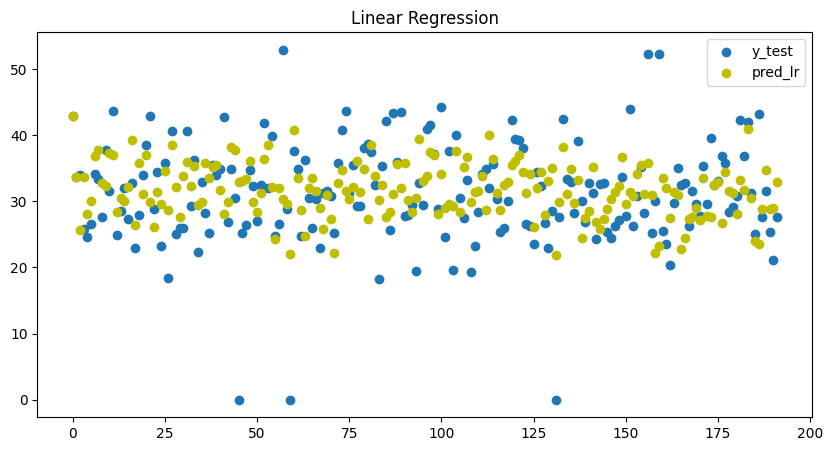

In [ ]:
# LR
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print('\n--- Linear Regression ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_lr))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_lr))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_lr))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_lr)), pred_lr, c='y', label='pred_lr')
plt.title('Linear Regression')
plt.legend()
plt.show()


--- Decision Tree Regressor ---
평균제곱오차(MSE) : 78.40718749999999
평균제곱오차(MSE) numpy : 78.40718749999999
평균제곱오차(MSE) 직접구현 : 78.40718749999998


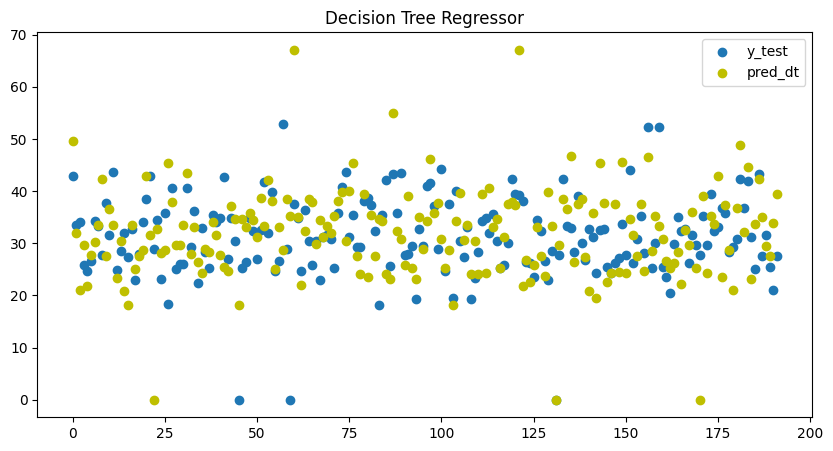

In [ ]:
# DT
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=0)
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)

print('\n--- Decision Tree Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_dt))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_dt))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_dt))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_dt)), pred_dt, c='y', label='pred_dt')
plt.title('Decision Tree Regressor')
plt.legend()
plt.show()


--- Random Forest Regressor ---
평균제곱오차(MSE) : 45.315124843750006
평균제곱오차(MSE) numpy : 45.315124843750006
평균제곱오차(MSE) 직접구현 : 45.315124843750006


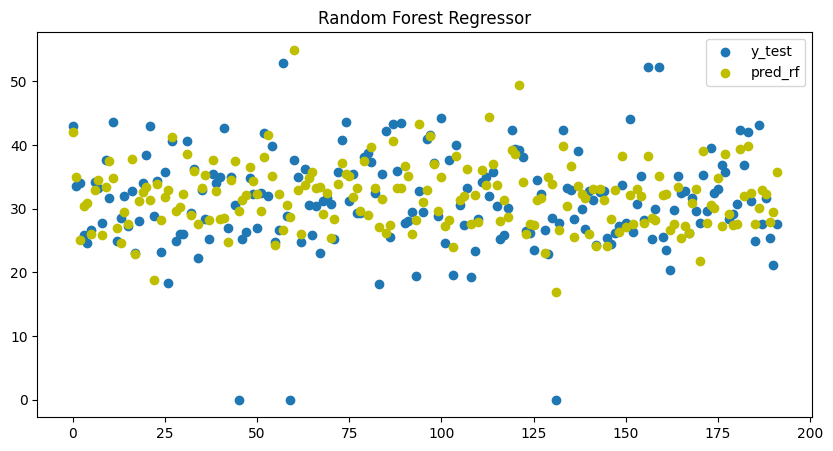

In [ ]:
# RF
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=0)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print('\n--- Random Forest Regressor ---')
print('평균제곱오차(MSE) :', mean_squared_error(y_test, pred_rf))
print('평균제곱오차(MSE) numpy :', mse_np(y_test, pred_rf))
print('평균제곱오차(MSE) 직접구현 :', mse(y_test, pred_rf))

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), y_test, label='y_test')
plt.scatter(range(len(pred_rf)), pred_rf, c='y', label='pred_rf')
plt.title('Random Forest Regressor')
plt.legend()
plt.show()